# AHL Pure Momentum

Replication of Man AHL's Pure Momentum program for the crypto universe.

**Core methodology:** Blend EWMAC (Exponentially Weighted Moving Average Crossover) signals
across six speeds, normalize by volatility, scale forecasts to a common magnitude, and size
positions with a per-instrument vol-targeting framework.

**Reference:** Rob Carver, *Systematic Trading* (2015); Man AHL "Need for Speed" (2023).

In [ ]:
from _setup import *
from common.metrics import compute_regime

## 1. Configuration

In [ ]:
START  = "2021-01-01"
END    = "2026-12-31"
IS_END = "2024-01-01"  # in-sample / out-of-sample split date

COST_BPS    = 20.0   # round-trip: 10 fee + 10 slippage
VOL_TARGET  = 0.20   # 20% annualised portfolio vol target
MAX_WEIGHT  = 0.20   # single-name cap
MAX_LEVERAGE = 2.0   # portfolio-level leverage cap

MIN_ADV_USD      = 1_000_000
MIN_HISTORY_DAYS = 90

# Six EWMAC speeds: (fast_span, slow_span) with 1:4 ratio
EWMAC_PAIRS = [(2, 8), (4, 16), (8, 32), (16, 64), (32, 128), (64, 256)]

FORECAST_CAP = 20.0  # absolute cap on combined forecast
FORECAST_TARGET_ABS = 10.0  # target mean |scaled forecast|

## 2. Data loading

In [ ]:
panel = load_daily_bars(start=START, end=END)
panel = filter_universe(panel, min_adv_usd=MIN_ADV_USD, min_history_days=MIN_HISTORY_DAYS)

# Wrapped / staked / bridged tokens that duplicate native asset exposure
EXCLUDE_SYMBOLS = {
    "WBTC-USD", "CBETH-USD", "WETH-USD", "STETH-USD", "RETH-USD",
    "MSOL-USD", "JITOSOLSOL-USD", "LSETH-USD",
}
_before = panel["symbol"].nunique()
panel = panel[~panel["symbol"].isin(EXCLUDE_SYMBOLS)]
_after = panel["symbol"].nunique()
if _before != _after:
    print(f"[universe] Dropped {_before - _after} wrapped/staked tokens")

close_wide    = panel.pivot(index="ts", columns="symbol", values="close")
returns_wide  = close_wide.pct_change(fill_method=None)
universe_wide = panel.pivot(index="ts", columns="symbol", values="in_universe").fillna(False).astype(bool)

btc_equity = compute_btc_benchmark(panel)

n_symbols = universe_wide.sum(axis=1)
print(f"Universe: {close_wide.columns.size} total symbols, "
      f"median {int(n_symbols.median())} in-universe on any given day")
print(f"Date range: {close_wide.index.min().date()} to {close_wide.index.max().date()}")

[data] Loading cached daily bars from /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/_cache/bars_1d_2021-01-01_2026-12-31.parquet
[universe] Dropped 3 wrapped/staked tokens
Universe: 359 total symbols, median 62 in-universe on any given day
Date range: 2021-01-02 to 2026-03-07


/Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/data.py:209: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("symbol", group_keys=False).apply(_per_symbol)
/var/folders/_n/5w8bl1bx1mv_wyxmz1qm5blr0000gn/T/ipykernel_20084/3096637832.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  universe_wide = panel.pivot(index="ts", columns="symbol", values="in_universe").fillna(False).astype(bool)


## 3. EWMAC signal engine

The canonical EWMAC forecast from Carver / Man AHL:

$$\text{raw forecast} = \frac{\text{EMA}_\text{fast} - \text{EMA}_\text{slow}}{\sigma_\text{daily}}$$

where $\sigma_\text{daily}$ is an EWM standard deviation of returns. The raw forecast is then
**scaled** so that $\text{median}(|\text{forecast}|) = 10$ (the "forecast scalar"), making
forecasts comparable across speeds and instruments.

In [112]:
def ewmac_raw_forecast(
    close: pd.DataFrame,
    returns: pd.DataFrame,
    fast_span: int,
    slow_span: int,
    vol_span: int | None = None,
) -> pd.DataFrame:
    """Vol-normalised EWMAC raw forecast (wide-format).

    raw_forecast = (EMA_fast - EMA_slow) / ewm_vol
    """
    if vol_span is None:
        vol_span = max(slow_span, 36)

    fast_ema = close.ewm(span=fast_span, min_periods=fast_span).mean()
    slow_ema = close.ewm(span=slow_span, min_periods=slow_span).mean()

    daily_vol = returns.ewm(span=vol_span, min_periods=vol_span).std()
    daily_vol_price = daily_vol * close

    raw = (fast_ema - slow_ema) / daily_vol_price.replace(0, np.nan)
    return raw


def estimate_forecast_scalar(
    raw_forecast: pd.DataFrame,
    target_abs: float = 10.0,
    min_periods: int = 252,
) -> pd.DataFrame:
    """Expanding-window median-based forecast scalar.

    scalar(t) = target_abs / expanding_median(|raw_forecast|)(t)
    Pooled across all instruments at each timestamp for robustness.
    """
    abs_fc = raw_forecast.abs()
    pooled_median = abs_fc.stack().groupby(level=0).median()
    expanding_median = pooled_median.expanding(min_periods=min_periods).median()
    scalar = target_abs / expanding_median.replace(0, np.nan)
    scalar = scalar.clip(upper=100.0)
    return scalar


def ewmac_scaled_forecast(
    close: pd.DataFrame,
    returns: pd.DataFrame,
    fast_span: int,
    slow_span: int,
    target_abs: float = 10.0,
) -> pd.DataFrame:
    """Produce a scaled EWMAC forecast for a single speed."""
    raw = ewmac_raw_forecast(close, returns, fast_span, slow_span)
    scalar = estimate_forecast_scalar(raw, target_abs=target_abs)
    scaled = raw.mul(scalar, axis=0)
    return scaled

In [113]:
forecasts = {}
for fast, slow in EWMAC_PAIRS:
    label = f"EWMAC_{fast}_{slow}"
    forecasts[label] = ewmac_scaled_forecast(
        close_wide, returns_wide, fast, slow, target_abs=FORECAST_TARGET_ABS,
    )
    med_abs = forecasts[label].abs().stack().median()
    print(f"  {label:>14s}  median|fc| = {med_abs:5.1f}")

print(f"\n{len(forecasts)} EWMAC speeds computed.")

       EWMAC_2_8  median|fc| =  10.8
      EWMAC_4_16  median|fc| =  10.8
      EWMAC_8_32  median|fc| =  10.8
     EWMAC_16_64  median|fc| =  10.9
    EWMAC_32_128  median|fc| =  10.4
    EWMAC_64_256  median|fc| =   9.2

6 EWMAC speeds computed.


## 4. Forecast combination

Equal-weight blend of all six speeds, capped at $\pm 20$, then clipped to $[0, 20]$ for
long-only crypto spot.

In [114]:
fc_stack = np.stack([f.values for f in forecasts.values()], axis=0)
combined_raw = pd.DataFrame(
    np.nanmean(fc_stack, axis=0),
    index=close_wide.index,
    columns=close_wide.columns,
)

combined_forecast = combined_raw.clip(-FORECAST_CAP, FORECAST_CAP)
combined_forecast_long = combined_forecast.clip(lower=0.0)

print(f"Combined forecast — median|fc|: {combined_forecast.abs().stack().median():.1f}")
print(f"Long-only clip    — median|fc|: {combined_forecast_long.abs().stack().dropna().loc[lambda x: x > 0].median():.1f}")
print(f"Fraction positive: {(combined_forecast_long.stack() > 0).mean():.1%}")

Combined forecast — median|fc|: 9.3
Long-only clip    — median|fc|: 5.5
Fraction positive: 27.6%


/var/folders/_n/5w8bl1bx1mv_wyxmz1qm5blr0000gn/T/ipykernel_20084/2601562142.py:3: RuntimeWarning: Mean of empty slice
  np.nanmean(fc_stack, axis=0),


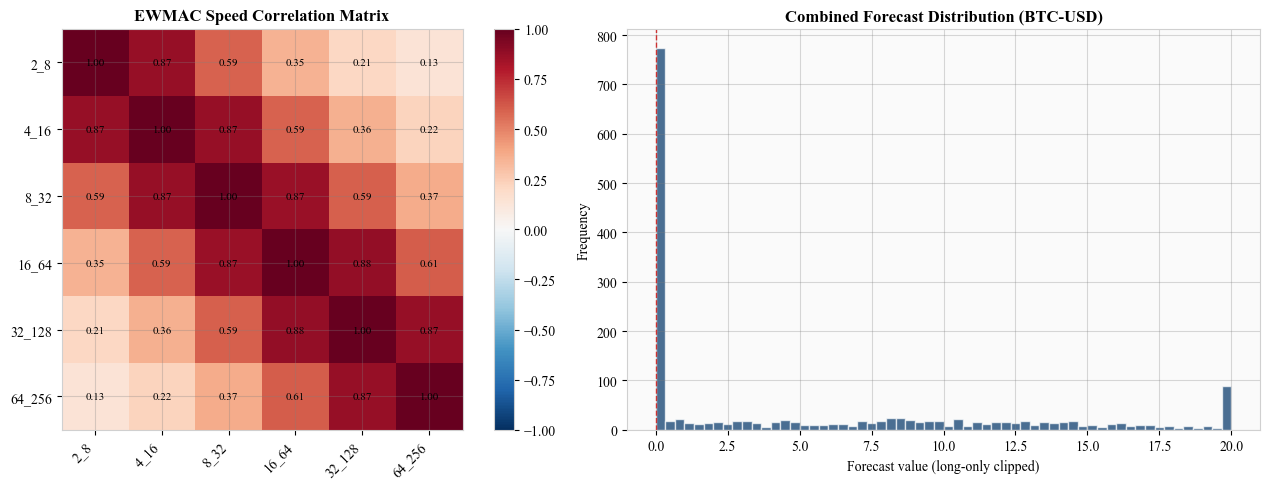

In [115]:
# Correlation matrix across EWMAC speeds (pooled across instruments)
speed_labels = list(forecasts.keys())
fc_flat = pd.DataFrame({
    lbl: forecasts[lbl].stack().dropna() for lbl in speed_labels
})
corr = fc_flat.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(speed_labels)))
axes[0].set_xticklabels([s.replace("EWMAC_", "") for s in speed_labels], rotation=45, ha="right")
axes[0].set_yticks(range(len(speed_labels)))
axes[0].set_yticklabels([s.replace("EWMAC_", "") for s in speed_labels])
for i in range(len(speed_labels)):
    for j in range(len(speed_labels)):
        axes[0].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
axes[0].set_title("EWMAC Speed Correlation Matrix", fontweight="bold")
fig.colorbar(im, ax=axes[0], fraction=0.046)

# Forecast distribution (BTC)
btc_col = [c for c in close_wide.columns if "BTC" in c.upper()]
if btc_col:
    btc_fc = combined_forecast_long[btc_col[0]].dropna()
    axes[1].hist(btc_fc.values, bins=60, color=NAVY, alpha=0.7, edgecolor="white")
    axes[1].axvline(0, color=RED, ls="--", lw=1)
    axes[1].set_title(f"Combined Forecast Distribution ({btc_col[0]})", fontweight="bold")
    axes[1].set_xlabel("Forecast value (long-only clipped)")
    axes[1].set_ylabel("Frequency")

fig.tight_layout()
plt.show()

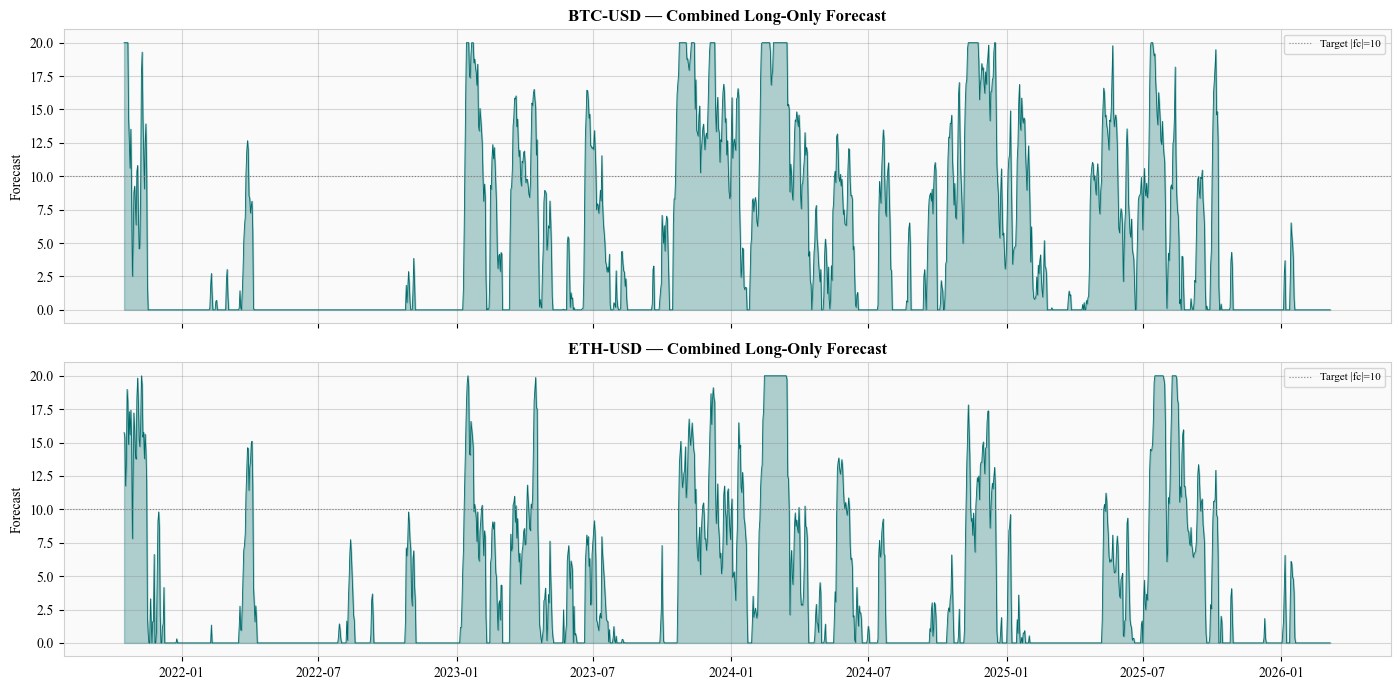

In [116]:
# Forecast time series for BTC and ETH
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, sym_stub in zip(axes, ["BTC", "ETH"]):
    col = [c for c in close_wide.columns if sym_stub in c.upper()]
    if not col:
        continue
    col = col[0]
    fc = combined_forecast_long[col].dropna()
    ax.fill_between(fc.index, fc.values, 0, alpha=0.3, color=TEAL)
    ax.plot(fc.index, fc.values, color=TEAL, lw=0.6)
    ax.axhline(FORECAST_TARGET_ABS, color=GRAY, ls=":", lw=0.8, label="Target |fc|=10")
    ax.set_ylabel("Forecast")
    ax.set_title(f"{col} — Combined Long-Only Forecast", fontweight="bold")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. Portfolio construction

Per-instrument weight (Carver canonical):

$$w_i = \frac{f_i}{10} \cdot \frac{\sigma_\text{target}}{\hat\sigma_i \cdot N_\text{active}}$$

Each instrument gets an equal slice of the vol budget ($\sigma_\text{target} / N$), scaled
by forecast strength. The $1/\hat\sigma_i$ term already ensures equal risk contribution
across instruments — no separate inverse-vol layer needed. Weights are then capped at
`MAX_WEIGHT` per name and `MAX_LEVERAGE` total.

In [ ]:
def build_ahl_weights(
    forecast: pd.DataFrame,
    returns_wide: pd.DataFrame,
    universe_wide: pd.DataFrame,
    vol_target: float = 0.20,
    vol_lookback: int = 63,
    max_weight: float = 0.20,
    max_leverage: float = 2.0,
    forecast_cap: float = 20.0,
) -> pd.DataFrame:
    """Convert combined forecast into portfolio weights (Carver canonical).

    w_i = (fc_i / 10) * (vol_target / inst_vol_i) / N_active

    Each instrument gets an equal slice of the vol budget, scaled by
    forecast strength.  The 1/vol_i term already ensures equal risk
    contribution — no separate inv-vol layer needed.
    """
    inst_vol = (
        returns_wide.ewm(span=vol_lookback, min_periods=max(20, vol_lookback // 2))
        .std() * np.sqrt(ANN_FACTOR)
    )
    mask = universe_wide.reindex_like(forecast).fillna(False)
    fc_norm = forecast.clip(-forecast_cap, forecast_cap) / FORECAST_TARGET_ABS

    n_active = mask.sum(axis=1).replace(0, np.nan)
    weights = (fc_norm * (vol_target / inst_vol.replace(0, np.nan))).div(n_active, axis=0)
    weights = weights.where(mask, 0.0).fillna(0.0)

    weights = apply_position_limit_wide(weights, max_wt=max_weight)

    gross = weights.abs().sum(axis=1)
    scale = (max_leverage / gross).clip(upper=1.0).fillna(1.0)
    weights = weights.mul(scale, axis=0)

    return weights

In [118]:
# Base weights: instrument-level vol sizing only (no portfolio overlay)
weights = build_ahl_weights(
    combined_forecast_long, returns_wide, universe_wide,
    vol_target=VOL_TARGET, max_weight=MAX_WEIGHT, max_leverage=MAX_LEVERAGE,
)

# Variant: add portfolio-level vol targeting overlay for comparison
weights_vol_overlay = apply_vol_targeting(
    weights.copy(), returns_wide,
    vol_target=VOL_TARGET, lookback=42, max_leverage=MAX_LEVERAGE,
)

for label, w in [("Base", weights), ("+ Vol Overlay", weights_vol_overlay)]:
    gross = w.abs().sum(axis=1)
    n_held = (w.abs() > 1e-6).sum(axis=1)
    print(f"{label:>15s}  |  avg gross: {gross.mean():.2f}  "
          f"avg positions: {n_held.mean():.1f}  max gross: {gross.max():.2f}")

           Base  |  avg gross: 0.05  avg positions: 23.1  max gross: 0.82
  + Vol Overlay  |  avg gross: 0.09  avg positions: 23.1  max gross: 1.65


## 6. Backtest and performance

In [119]:
strat = quick_backtest(weights, returns_wide, cost_bps=COST_BPS, label="AHL Pure Momentum")
strat_overlay = quick_backtest(weights_vol_overlay, returns_wide, cost_bps=COST_BPS, label="AHL + Vol Overlay")

# BTC buy-and-hold benchmark
btc_col = [c for c in close_wide.columns if "BTC" in c.upper()]
if btc_col:
    btc_wt = pd.DataFrame(0.0, index=weights.index, columns=weights.columns)
    btc_wt[btc_col[0]] = 1.0
    bh_btc = quick_backtest(btc_wt, returns_wide, cost_bps=COST_BPS, label="BTC B&H")
else:
    bh_btc = {"label": "BTC B&H", "metrics": {}, "equity": pd.Series(dtype=float)}

# Equal-weight crypto buy-and-hold
ew_wt = universe_wide.astype(float).div(
    universe_wide.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0.0)
bh_ew = quick_backtest(ew_wt, returns_wide, cost_bps=COST_BPS, label="EW Crypto B&H")

results = [strat, strat_overlay, bh_btc, bh_ew]

In [120]:
metrics_table(results)

,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
AHL Pure Momentum,0.163408,3.0%,5.6%,0.55,0.61,0.27,-10.8%,39.0%,-0.13,26.337809,1891,0.01,4.5%
AHL + Vol Overlay,0.320989,5.5%,10.6%,0.56,0.63,0.28,-19.5%,39.0%,0.07,28.089282,1891,0.03,8.6%
BTC B&H,1.084198,15.2%,58.8%,0.53,0.76,0.20,-76.7%,49.5%,0.14,3.836272,1891,0.00,99.9%
EW Crypto B&H,-0.916614,-38.1%,81.7%,-0.17,-0.22,-0.40,-94.9%,48.5%,-0.49,5.033597,1891,0.03,95.2%


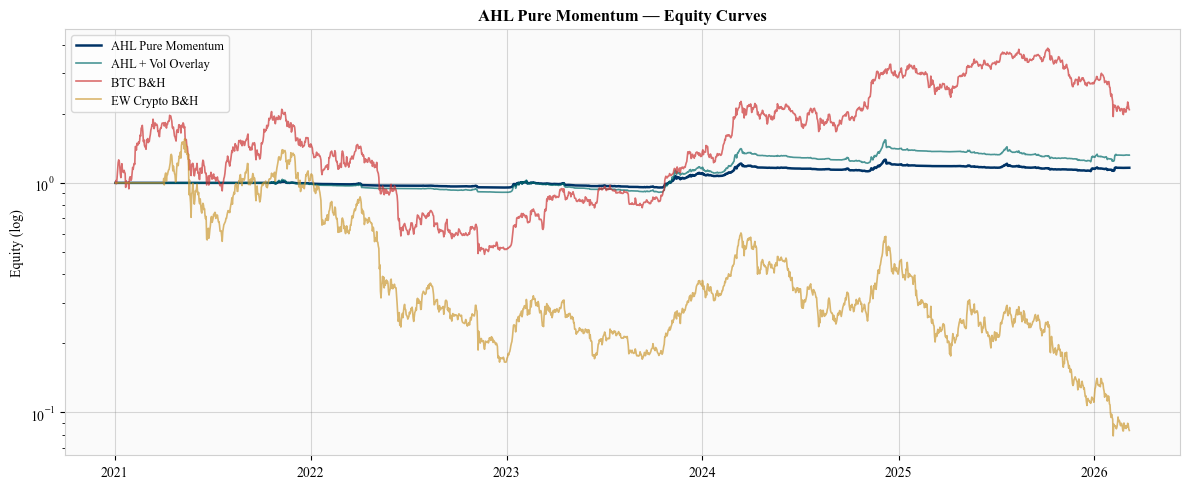

In [121]:
plot_equity(results, title="AHL Pure Momentum — Equity Curves")
plt.show()

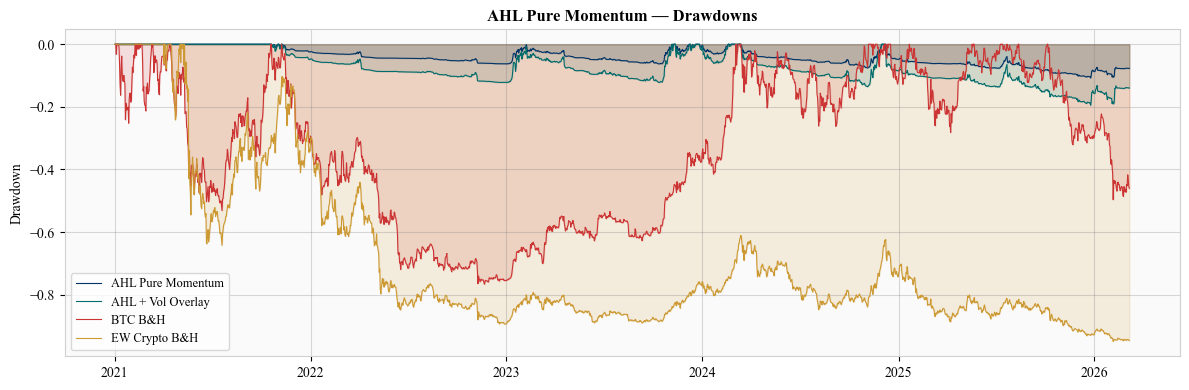

In [122]:
plot_drawdowns(results, title="AHL Pure Momentum — Drawdowns")
plt.show()

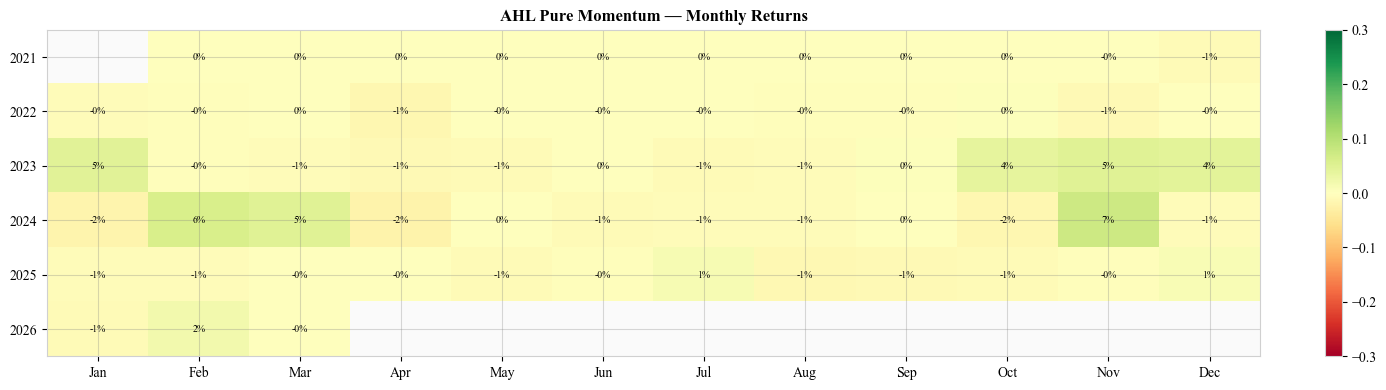

In [123]:
# Monthly return heatmap
if strat["equity"].any():
    eq = strat["equity"]
    monthly = eq.resample("ME").last().pct_change().dropna()
    monthly_df = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "ret": monthly.values,
    })
    pivot = monthly_df.pivot(index="year", columns="month", values="ret")
    pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"]

    fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.4)))
    im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-0.3, vmax=0.3)
    ax.set_xticks(range(12))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index)
    for i in range(len(pivot)):
        for j in range(12):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=7)
    ax.set_title("AHL Pure Momentum — Monthly Returns", fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.02)
    fig.tight_layout()
    plt.show()

## 7. Decomposition by EWMAC speed

Backtest each EWMAC speed individually to show performance characteristics
per speed and the diversification benefit of blending.

In [ ]:
speed_results = []
for label, fc in forecasts.items():
    fc_long = fc.clip(lower=0.0)
    w = build_ahl_weights(
        fc_long, returns_wide, universe_wide,
        vol_target=VOL_TARGET, max_weight=MAX_WEIGHT, max_leverage=MAX_LEVERAGE,
    )
    r = quick_backtest(w, returns_wide, cost_bps=COST_BPS, label=label)
    speed_results.append(r)

# Add the blended strategy for comparison
speed_results.append(strat)

metrics_table(speed_results)

,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
EWMAC_2_8,0.020251,0.4%,10.0%,0.09,0.11,0.02,-23.6%,38.4%,1.22,28.945902,1891,0.04,8.9%
EWMAC_4_16,0.264143,4.6%,9.3%,0.53,0.62,0.33,-13.9%,39.6%,0.40,18.132767,1891,0.02,8.0%
EWMAC_8_32,0.248222,4.4%,8.2%,0.56,0.61,0.33,-13.2%,40.6%,-0.20,22.138079,1891,0.01,6.5%
EWMAC_16_64,0.109883,2.0%,6.7%,0.34,0.35,0.16,-12.4%,40.2%,-0.31,24.663760,1891,0.01,5.1%
EWMAC_32_128,0.042579,0.8%,4.5%,0.20,0.20,0.09,-9.3%,38.7%,-0.48,21.688339,1891,0.00,3.5%
EWMAC_64_256,-0.009087,-0.2%,2.9%,-0.05,-0.04,-0.02,-8.2%,33.9%,-0.76,25.942674,1891,0.00,2.3%
AHL Pure Momentum,0.163408,3.0%,5.6%,0.55,0.61,0.27,-10.8%,39.0%,-0.13,26.337809,1891,0.01,4.5%


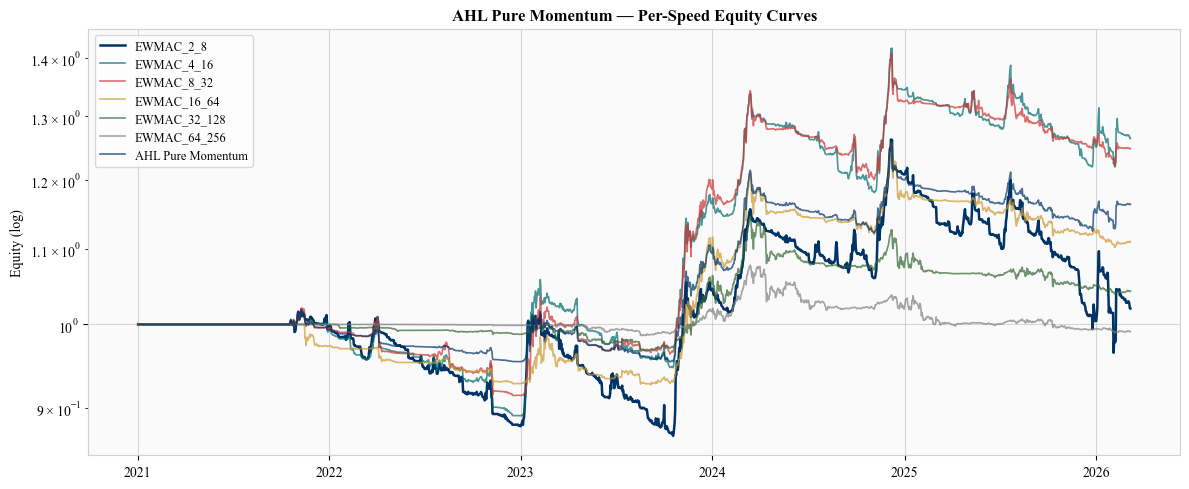

In [125]:
plot_equity(speed_results, title="AHL Pure Momentum — Per-Speed Equity Curves")
plt.show()

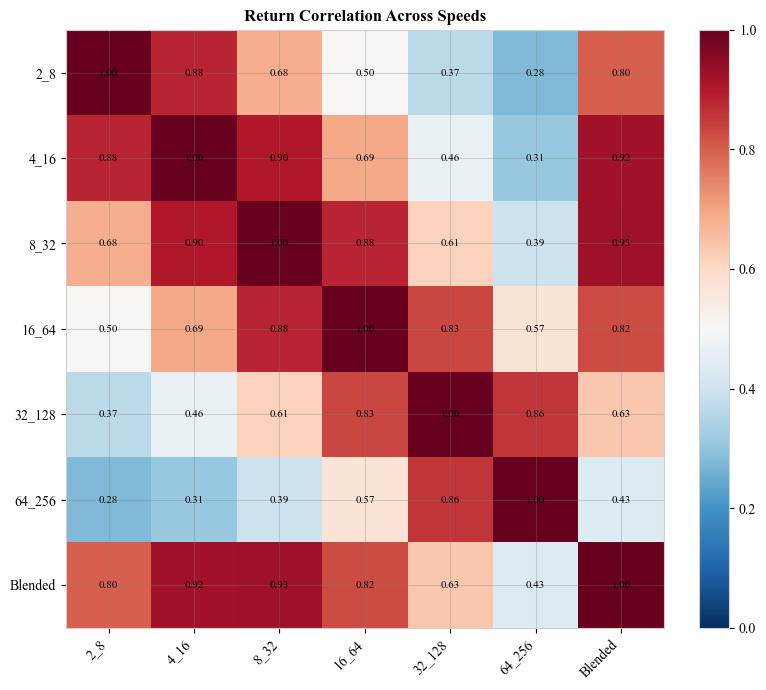

In [126]:
# Return correlation across speeds
speed_rets = {}
for r in speed_results:
    if r["equity"].empty:
        continue
    speed_rets[r["label"]] = r["equity"].pct_change().dropna()

if speed_rets:
    ret_df = pd.DataFrame(speed_rets)
    corr = ret_df.corr()

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=0, vmax=1)
    labels = [s.replace("EWMAC_", "").replace("AHL Pure Momentum", "Blended") for s in corr.columns]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title("Return Correlation Across Speeds", fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    plt.show()

## 8. Sensitivity analysis

Sweep key parameters to gauge robustness.

In [127]:
# --- Vol target sweep ---
vol_targets = [0.10, 0.15, 0.20, 0.25, 0.30]
vol_sweep = []
for vt in vol_targets:
    w = build_ahl_weights(
        combined_forecast_long, returns_wide, universe_wide,
        vol_target=vt, max_weight=MAX_WEIGHT, max_leverage=MAX_LEVERAGE,
    )
    r = quick_backtest(w, returns_wide, cost_bps=COST_BPS, label=f"vol_target={vt:.0%}")
    vol_sweep.append(r)

metrics_table(vol_sweep)

,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
vol_target=10%,0.080808,1.5%,2.8%,0.55,0.61,0.27,-5.5%,39.0%,-0.13,26.337809,1891,0.01,2.3%
vol_target=15%,0.121917,2.2%,4.2%,0.55,0.61,0.27,-8.2%,39.0%,-0.13,26.337809,1891,0.01,3.4%
vol_target=20%,0.163408,3.0%,5.6%,0.55,0.61,0.27,-10.8%,39.0%,-0.13,26.337809,1891,0.01,4.5%
vol_target=25%,0.205207,3.7%,7.0%,0.55,0.61,0.27,-13.3%,39.0%,-0.13,26.337809,1891,0.02,5.7%
vol_target=30%,0.247238,4.4%,8.4%,0.55,0.61,0.28,-15.8%,39.0%,-0.13,26.337809,1891,0.02,6.8%


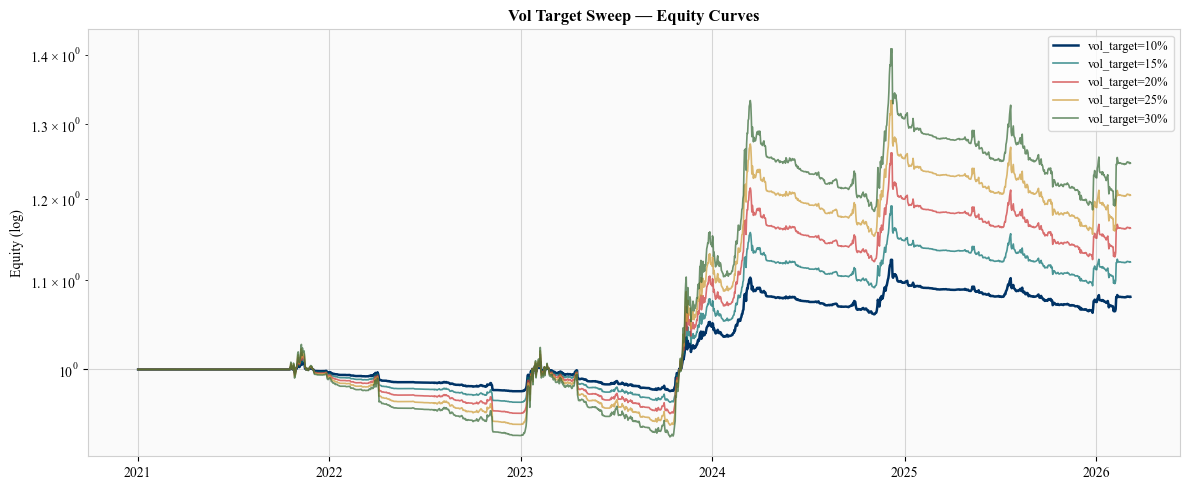

In [128]:
plot_equity(vol_sweep, title="Vol Target Sweep — Equity Curves")
plt.show()

In [129]:
# --- Max position limit sweep ---
pos_limits = [0.10, 0.15, 0.20, 0.30, 0.50]
pos_sweep = []
for ml in pos_limits:
    w = build_ahl_weights(
        combined_forecast_long, returns_wide, universe_wide,
        vol_target=VOL_TARGET, max_weight=ml, max_leverage=MAX_LEVERAGE,
    )
    r = quick_backtest(w, returns_wide, cost_bps=COST_BPS, label=f"max_wt={ml:.0%}")
    pos_sweep.append(r)

metrics_table(pos_sweep)

,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
max_wt=10%,0.177033,3.2%,5.8%,0.57,0.64,0.27,-12.0%,38.8%,0.04,25.233028,1891,0.01,4.5%
max_wt=15%,0.168813,3.1%,5.7%,0.56,0.62,0.27,-11.3%,38.8%,-0.10,25.510554,1891,0.01,4.5%
max_wt=20%,0.163408,3.0%,5.6%,0.55,0.61,0.27,-10.8%,39.0%,-0.13,26.337809,1891,0.01,4.5%
max_wt=30%,0.143665,2.6%,5.4%,0.51,0.55,0.25,-10.5%,39.3%,-0.53,26.491669,1891,0.01,4.5%
max_wt=50%,0.138724,2.5%,5.3%,0.50,0.53,0.25,-10.1%,39.8%,-0.59,28.090988,1891,0.01,4.5%


In [130]:
# --- Speed subset analysis: fast-only, slow-only, all ---
fast_labels = ["EWMAC_2_8", "EWMAC_4_16", "EWMAC_8_32"]
slow_labels = ["EWMAC_16_64", "EWMAC_32_128", "EWMAC_64_256"]

def blend_subset(labels):
    fc_sub = np.stack([forecasts[l].values for l in labels], axis=0)
    combined = pd.DataFrame(
        np.nanmean(fc_sub, axis=0), index=close_wide.index, columns=close_wide.columns,
    ).clip(-FORECAST_CAP, FORECAST_CAP).clip(lower=0.0)
    return build_ahl_weights(
        combined, returns_wide, universe_wide,
        vol_target=VOL_TARGET, max_weight=MAX_WEIGHT, max_leverage=MAX_LEVERAGE,
    )

subset_results = [
    quick_backtest(blend_subset(fast_labels), returns_wide, cost_bps=COST_BPS, label="Fast Only (2-32)"),
    quick_backtest(blend_subset(slow_labels), returns_wide, cost_bps=COST_BPS, label="Slow Only (16-256)"),
    strat,
]

metrics_table(subset_results)

/var/folders/_n/5w8bl1bx1mv_wyxmz1qm5blr0000gn/T/ipykernel_20084/2046981693.py:8: RuntimeWarning: Mean of empty slice
  np.nanmean(fc_sub, axis=0), index=close_wide.index, columns=close_wide.columns,
/var/folders/_n/5w8bl1bx1mv_wyxmz1qm5blr0000gn/T/ipykernel_20084/2046981693.py:8: RuntimeWarning: Mean of empty slice
  np.nanmean(fc_sub, axis=0), index=close_wide.index, columns=close_wide.columns,


,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
Fast Only (2-32),0.241095,4.3%,8.6%,0.53,0.61,0.30,-14.4%,39.5%,0.43,19.528713,1891,0.02,7.3%
Slow Only (16-256),0.024348,0.5%,4.3%,0.13,0.13,0.05,-8.8%,40.4%,-0.60,21.232951,1891,0.00,3.4%
AHL Pure Momentum,0.163408,3.0%,5.6%,0.55,0.61,0.27,-10.8%,39.0%,-0.13,26.337809,1891,0.01,4.5%


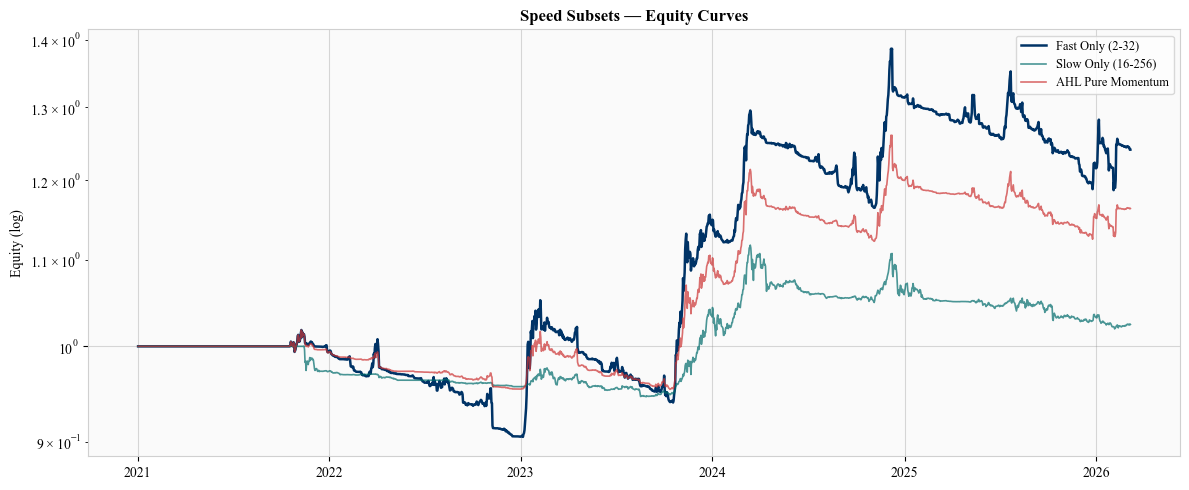

In [131]:
plot_equity(subset_results, title="Speed Subsets — Equity Curves")
plt.show()

## 9. Regime analysis

Performance conditioned on BTC market regime (BULL / BEAR / CHOP).

In [132]:
regime = compute_regime(returns_wide, window=21)

strat_ret = strat["equity"].pct_change().dropna()
btc_ret_series = bh_btc["equity"].pct_change().dropna() if not bh_btc["equity"].empty else pd.Series(dtype=float)

common_idx = strat_ret.index.intersection(regime.index)
regime_aligned = regime.reindex(common_idx)
strat_ret_aligned = strat_ret.reindex(common_idx)

regime_stats = []
for r_label in ["BULL", "BEAR", "CHOP"]:
    mask = regime_aligned == r_label
    sub = strat_ret_aligned[mask]
    if len(sub) < 30:
        continue
    eq = (1 + sub).cumprod()
    m = compute_metrics(eq)
    m["regime"] = r_label
    m["n_days"] = int(mask.sum())
    m["pct_time"] = float(mask.mean())

    if not btc_ret_series.empty:
        btc_sub = btc_ret_series.reindex(sub.index).dropna()
        common = sub.index.intersection(btc_sub.index)
        if len(common) > 30:
            m["corr_with_btc"] = float(sub.loc[common].corr(btc_sub.loc[common]))

    regime_stats.append(m)

regime_df = pd.DataFrame(regime_stats).set_index("regime")
for c in ["cagr", "vol", "max_dd", "hit_rate", "pct_time"]:
    if c in regime_df.columns:
        regime_df[c] = regime_df[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
for c in ["sharpe", "sortino", "calmar", "skewness", "corr_with_btc"]:
    if c in regime_df.columns:
        regime_df[c] = regime_df[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
regime_df

,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,pct_time,corr_with_btc
regime,,,,,,,,,,,,,
BULL,0.502324,27.2%,8.3%,2.95,3.22,6.13,-4.4%,46.8%,-0.51,12.386743,617,32.6%,0.40
BEAR,-0.099901,-6.0%,2.8%,-2.21,-2.92,-0.47,-12.7%,29.7%,7.71,158.126015,617,32.6%,0.20
CHOP,-0.139644,-8.0%,4.1%,-2.03,-1.81,-0.50,-16.1%,40.6%,-1.90,20.431969,656,34.7%,0.41


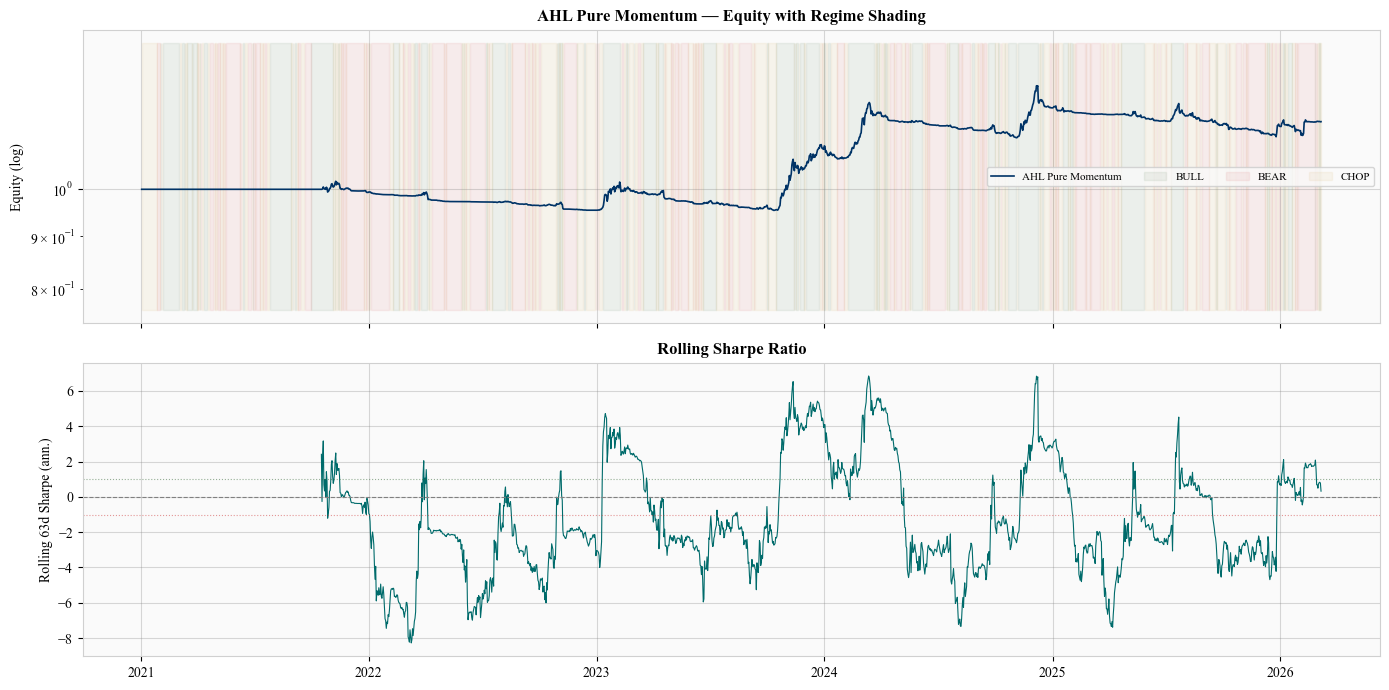

In [133]:
# Rolling 63-day Sharpe ratio
rolling_ret = strat_ret.rolling(63, min_periods=42)
rolling_sharpe = (rolling_ret.mean() / rolling_ret.std()) * np.sqrt(ANN_FACTOR)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: equity with regime shading
ax = axes[0]
eq = strat["equity"]
ax.plot(eq.index, eq.values, color=NAVY, lw=1.2, label="AHL Pure Momentum")
regime_colors = {"BULL": GREEN, "BEAR": RED, "CHOP": GOLD}
for r_label, color in regime_colors.items():
    mask = regime.reindex(eq.index) == r_label
    if mask.any():
        ax.fill_between(eq.index, eq.values.min() * 0.8, eq.values.max() * 1.1,
                        where=mask.values, alpha=0.07, color=color, label=r_label)
ax.set_yscale("log")
ax.set_ylabel("Equity (log)")
ax.set_title("AHL Pure Momentum — Equity with Regime Shading", fontweight="bold")
ax.legend(fontsize=8, ncol=4)

# Bottom: rolling Sharpe
ax = axes[1]
ax.plot(rolling_sharpe.index, rolling_sharpe.values, color=TEAL, lw=0.8)
ax.axhline(0, color=GRAY, ls="--", lw=0.8)
ax.axhline(1.0, color=GREEN, ls=":", lw=0.8, alpha=0.5)
ax.axhline(-1.0, color=RED, ls=":", lw=0.8, alpha=0.5)
ax.set_ylabel("Rolling 63d Sharpe (ann.)")
ax.set_title("Rolling Sharpe Ratio", fontweight="bold")

fig.tight_layout()
plt.show()

In [134]:
# Crisis participation: capture rate during top/bottom BTC deciles
if not btc_ret_series.empty:
    common = strat_ret.index.intersection(btc_ret_series.index)
    s = strat_ret.reindex(common)
    b = btc_ret_series.reindex(common)

    btc_monthly = b.resample("ME").sum()
    strat_monthly = s.resample("ME").sum()
    common_m = btc_monthly.index.intersection(strat_monthly.index)
    btc_m = btc_monthly.loc[common_m]
    strat_m = strat_monthly.loc[common_m]

    top_months = btc_m >= btc_m.quantile(0.80)
    bottom_months = btc_m <= btc_m.quantile(0.20)

    top_capture = strat_m[top_months].mean() / btc_m[top_months].mean() if top_months.sum() > 0 else np.nan
    bottom_capture = strat_m[bottom_months].mean() / btc_m[bottom_months].mean() if bottom_months.sum() > 0 else np.nan

    print(f"Upside capture  (top-20% BTC months):    {top_capture:.1%}")
    print(f"Downside capture (bottom-20% BTC months): {bottom_capture:.1%}")
    print(f"Capture ratio:                            {top_capture / bottom_capture:.2f}" if bottom_capture != 0 else "")

Upside capture  (top-20% BTC months):    7.6%
Downside capture (bottom-20% BTC months): 2.4%
Capture ratio:                            3.19


## 10. In-sample / out-of-sample validation

Split the backtest at `IS_END` to check whether the strategy's structural choices
(EWMAC speeds, equal-weight blend, vol target, position limits) hold up on unseen data.
The forecast scalar is estimated with an expanding window, so there is no explicit IS
fitting — this tests the robustness of the overall design.

**Ref:** Man AHL, "A Trend Following Deep Dive: AI, Agents and Trend" (Oct 2025) flags
IS/OOS testing as a core best practice for trend-following research.

In [ ]:
is_end_ts = pd.Timestamp(IS_END)
is_mask  = weights.index < is_end_ts
oos_mask = weights.index >= is_end_ts

# Strategy
is_strat  = quick_backtest(weights[is_mask],  returns_wide, cost_bps=COST_BPS, label="IS: AHL Momentum")
oos_strat = quick_backtest(weights[oos_mask], returns_wide, cost_bps=COST_BPS, label="OOS: AHL Momentum")

# BTC benchmark
if btc_col:
    is_btc  = quick_backtest(btc_wt[is_mask],  returns_wide, cost_bps=COST_BPS, label="IS: BTC B&H")
    oos_btc = quick_backtest(btc_wt[oos_mask], returns_wide, cost_bps=COST_BPS, label="OOS: BTC B&H")
else:
    is_btc = oos_btc = {"label": "", "metrics": {}, "equity": pd.Series(dtype=float)}

isoos_results = [is_strat, oos_strat, is_btc, oos_btc]
metrics_table(isoos_results)

In [ ]:
# Full-period equity with IS/OOS split marker
fig, ax = plot_equity(
    [is_strat, oos_strat, is_btc, oos_btc],
    title="IS / OOS — Equity Curves",
)
ax.axvline(is_end_ts, color=GRAY, ls="--", lw=1.2, label=f"IS/OOS split ({IS_END})")
ax.legend(fontsize=9, frameon=True, facecolor="white", edgecolor=LGRAY)
plt.show()

# Key metric deltas
def _get(r, key):
    return r.get("metrics", {}).get(key, float("nan"))

delta_sharpe = _get(oos_strat, "sharpe") - _get(is_strat, "sharpe")
delta_cagr   = _get(oos_strat, "cagr")   - _get(is_strat, "cagr")
delta_dd     = _get(oos_strat, "max_dd")  - _get(is_strat, "max_dd")

print(f"OOS vs IS deltas:")
print(f"  Sharpe : {delta_sharpe:+.2f}")
print(f"  CAGR   : {delta_cagr:+.1%}")
print(f"  Max DD : {delta_dd:+.1%}")

## 11. Adaptive speed selection

The equal-weight blend of 6 EWMAC speeds is regime-agnostic. In trending markets
(BULL), slower speeds have better signal-to-noise; in volatile/reversing markets
(BEAR/CHOP), faster speeds capture turns earlier. We tilt the speed blend weights
by the BTC regime computed in Section 9.

In [ ]:
SPEED_WEIGHTS = {
    "BULL":  np.array([0.05, 0.05, 0.10, 0.20, 0.30, 0.30]),
    "BEAR":  np.array([0.30, 0.30, 0.20, 0.10, 0.05, 0.05]),
    "CHOP":  np.array([1/6]*6),
}

speed_labels = list(forecasts.keys())
fc_stack = np.stack([forecasts[l].values for l in speed_labels], axis=0)  # (6, T, N)

regime_wt = np.column_stack([SPEED_WEIGHTS[r] for r in regime.values])    # (6, T)

adaptive_fc = pd.DataFrame(
    np.einsum("st,stn->tn", regime_wt, fc_stack) / regime_wt.sum(axis=0, keepdims=True).T,
    index=close_wide.index, columns=close_wide.columns,
).clip(-FORECAST_CAP, FORECAST_CAP).clip(lower=0.0)

weights_adaptive = build_ahl_weights(
    adaptive_fc, returns_wide, universe_wide,
    vol_target=VOL_TARGET, max_weight=MAX_WEIGHT, max_leverage=MAX_LEVERAGE,
)
adaptive_strat = quick_backtest(weights_adaptive, returns_wide, cost_bps=COST_BPS, label="Adaptive Speed")

adaptive_results = [strat, adaptive_strat, bh_btc]
metrics_table(adaptive_results)

## 12. Cross-sectional momentum overlay

Pure TSMOM treats each asset independently. A cross-sectional tilt boosts
assets whose forecast is strongest *relative to peers* and dampens laggards,
exploiting the "winners keep winning" effect within crypto. The tilt is
multiplicative (0.5x–1.5x) and re-normalised so total gross exposure is unchanged.

In [ ]:
cs_rank = combined_forecast_long.rank(axis=1, pct=True)
cs_tilt = 0.5 + cs_rank  # range [0.5, 1.5]

weights_cs = weights * cs_tilt

# Re-normalise to match base gross exposure each day
base_gross = weights.abs().sum(axis=1).replace(0, np.nan)
cs_gross = weights_cs.abs().sum(axis=1).replace(0, np.nan)
weights_cs = weights_cs.mul(base_gross / cs_gross, axis=0).fillna(0.0)

weights_cs = apply_position_limit_wide(weights_cs, max_wt=MAX_WEIGHT)
gross = weights_cs.abs().sum(axis=1)
scale = (MAX_LEVERAGE / gross).clip(upper=1.0).fillna(1.0)
weights_cs = weights_cs.mul(scale, axis=0)

cs_strat = quick_backtest(weights_cs, returns_wide, cost_bps=COST_BPS, label="TSMOM + CS Overlay")

cs_results = [strat, cs_strat, bh_btc]
metrics_table(cs_results)

## 13. Entry probability filter

Gate new entries on a walk-forward logistic regression estimate of
`P(fwd_21d_return > 0)`. Five features per asset — momentum, vol ratio, RSI,
ADX, and Bollinger %B — are trained on 365-day expanding windows and
tested on 63-day blocks. Positions where `p < 0.50` are zeroed out.

Inspired by notebook 04 (logreg probability filter), which found that a
regime-level filter was the most practical application of logistic regression
for trend strategies.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(span=period, min_periods=period).mean()
    loss = (-delta.clip(upper=0)).ewm(span=period, min_periods=period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

def _adx(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    atr = tr.ewm(span=period, min_periods=period).mean()
    up = high.diff(); down = -low.diff()
    plus_dm = up.where((up > down) & (up > 0), 0.0)
    minus_dm = down.where((down > up) & (down > 0), 0.0)
    plus_di = 100 * plus_dm.ewm(span=period, min_periods=period).mean() / atr.replace(0, np.nan)
    minus_di = 100 * minus_dm.ewm(span=period, min_periods=period).mean() / atr.replace(0, np.nan)
    dx = (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan) * 100
    return dx.ewm(span=period, min_periods=period).mean()

FEAT_COLS = ["ret_21d", "vol_ratio", "rsi_14", "adx_14", "bb_pctb"]
WF_MIN_TRAIN = 365
WF_TEST_STEP = 63
P_ENTER = 0.50

# Build features per asset in long format
feat_frames = []
symbols = close_wide.columns.tolist()
for sym in symbols:
    c = close_wide[sym].dropna()
    if len(c) < WF_MIN_TRAIN:
        continue
    r = returns_wide[sym].reindex(c.index)
    vol_10 = r.rolling(10).std()
    vol_63 = r.rolling(63).std()
    sma_20 = c.rolling(20).mean()
    std_20 = c.rolling(20).std()

    feat = pd.DataFrame({
        "ret_21d":   r.rolling(21).sum(),
        "vol_ratio": vol_10 / vol_63.replace(0, np.nan),
        "rsi_14":    _rsi(c, 14),
        "adx_14":    _adx(c, c, c, 14),  # approx with close as proxy for H/L
        "bb_pctb":   (c - (sma_20 - 2*std_20)) / (4*std_20).replace(0, np.nan),
    }, index=c.index)
    feat["symbol"] = sym
    feat["fwd_ret_21"] = r.rolling(21).sum().shift(-21)
    feat_frames.append(feat)

feat_all = pd.concat(feat_frames).dropna(subset=FEAT_COLS + ["fwd_ret_21"])
feat_all["target"] = (feat_all["fwd_ret_21"] > 0).astype(int)

# Walk-forward
dates = feat_all.index.unique().sort_values()
prob_records = []

for start_idx in range(WF_MIN_TRAIN, len(dates), WF_TEST_STEP):
    train_end = dates[start_idx]
    test_end_idx = min(start_idx + WF_TEST_STEP, len(dates))
    test_end = dates[test_end_idx - 1]

    train = feat_all.loc[:train_end]
    test  = feat_all.loc[train_end:test_end]
    test  = test[test.index > train_end]
    if len(train) < 500 or len(test) == 0:
        continue

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train[FEAT_COLS].values)
    y_tr = train["target"].values
    X_te = scaler.transform(test[FEAT_COLS].values)

    model = LogisticRegression(C=1.0, penalty="l2", max_iter=1000, solver="lbfgs")
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]

    for i, (idx, row) in enumerate(test.iterrows()):
        prob_records.append({"ts": idx, "symbol": row["symbol"], "prob": p[i]})

prob_df = pd.DataFrame(prob_records)
prob_wide = prob_df.pivot_table(index="ts", columns="symbol", values="prob")
print(f"Walk-forward probabilities: {len(prob_df):,} obs, "
      f"{prob_wide.columns.nunique()} assets, "
      f"mean p = {prob_df['prob'].mean():.3f}")

In [ ]:
prob_aligned = prob_wide.reindex_like(weights)

# Zero out weights where p < P_ENTER
weights_prob = weights.where(prob_aligned >= P_ENTER, 0.0).fillna(0.0)

weights_prob = apply_position_limit_wide(weights_prob, max_wt=MAX_WEIGHT)
gross = weights_prob.abs().sum(axis=1)
scale = (MAX_LEVERAGE / gross).clip(upper=1.0).fillna(1.0)
weights_prob = weights_prob.mul(scale, axis=0)

prob_strat = quick_backtest(weights_prob, returns_wide, cost_bps=COST_BPS, label="TSMOM + Prob Filter")

prob_results = [strat, prob_strat, bh_btc]
metrics_table(prob_results)

In [ ]:
all_variants = [strat, adaptive_strat, cs_strat, prob_strat, bh_btc]
metrics_table(all_variants)

fig, ax = plot_equity(all_variants, title="All Variants — Equity Curves")
plt.show()

fig, ax = plot_drawdowns(all_variants, title="All Variants — Drawdowns")
plt.show()